In [37]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# --- Funções de Análise ---

def find_model_files(root_folder):
    """Encontra pares de arquivos (h_matrix.txt, args.json) em uma pasta."""
    model_paths = []
    for dirpath, _, filenames in os.walk(root_folder):
        if 'h_matrix.txt' in filenames and 'args.json' in filenames:
            model_paths.append({
                "h_matrix": os.path.join(dirpath, 'h_matrix.txt'),
                "args": os.path.join(dirpath, 'args.json')
            })
    return model_paths

def get_average_h_matrix(model_paths):
    """Carrega todas as matrizes H e calcula a média."""
    if not model_paths:
        return None
    
    h_matrices = [np.loadtxt(p["h_matrix"], delimiter=',') for p in model_paths]
    
    # Empilha as matrizes e calcula a média ao longo do novo eixo (eixo 0)
    avg_h_matrix = np.mean(np.stack(h_matrices), axis=0)
    
    # Carrega os argumentos do primeiro modelo para obter os parâmetros da simulação
    with open(model_paths[0]['args'], 'r') as f:
        args = json.load(f)
        
    return avg_h_matrix, args

# Copiada diretamente da sua especificação para garantir consistência
def percept_preprocess(observation, num_percepts_list):
    """Pré-processa a observação para gerar um índice de percepção único."""
    percept = 0
    for which_feature in range(len(observation)):
        percept += int(observation[which_feature] * np.prod(num_percepts_list[:which_feature]))
    return percept

def get_prob_p(h_matrix, state_phi, timer_omega, colision_lambda, args):
    """Calcula p(ϕ, ω, λ) - a probabilidade de TROCAR de estado."""
    
    max_steps_per_trial = args['max_steps_per_episode'] // 20
    
    if args['colision']:
        num_percepts_list = [2, max_steps_per_trial, 2]
        observation = [state_phi, timer_omega, colision_lambda]
    else:
        num_percepts_list = [2, max_steps_per_trial]
        observation = [state_phi, timer_omega]
        
    percept = percept_preprocess(observation, num_percepts_list)
    
    # Extrai o vetor de pesos para esta percepção
    h_vector = h_matrix[:, percept]
    
    # Calcula a distribuição de probabilidade (standard ou softmax)
    if args['policy'] == 'standard':
        prob_distr = h_vector / np.sum(h_vector)
    elif args['policy'] == 'softmax':
        h_vector_mod = args['beta_softmax'] * (h_vector - np.max(h_vector))
        prob_distr = np.exp(h_vector_mod) / np.sum(np.exp(h_vector_mod))
    else:
        raise ValueError(f"Política desconhecida: {args['policy']}")

    # p(ϕ, ω, λ) é a probabilidade da AÇÃO 1 (trocar de estado)
    return prob_distr[1]

def calculate_strategy_metrics(h_matrix, args, state_phi, colision_lambda):
    """Calcula as equações (2), (3) e (4) para um estado fixo."""
    
    max_steps = args['max_steps_per_episode'] // 20
    dt = args['dt']
    
    # Array de probabilidades de troca p(ω) para cada tempo
    prob_p_array = np.array([get_prob_p(h_matrix, state_phi, omega, colision_lambda, args) for omega in range(max_steps)])
    
    # Array de probabilidades de NÃO troca (1 - p(ω))
    prob_no_switch = 1 - prob_p_array
    
    # Probabilidade de NÃO ter trocado até o tempo ω' (Equação 2, parte do produto)
    # cumprod calcula o produto acumulado: [p0, p0*p1, p0*p1*p2, ...]
    prob_survived_until = np.cumprod(prob_no_switch)
    # Precisamos deslocar, pois P(sobreviver até 0)=1, P(sobreviver até 1)=1-p(0), etc.
    prob_survived_until = np.insert(prob_survived_until, 0, 1)[:-1]

    # Equação (2): P(ω = ω') = p(ω') * P(sobreviveu até ω')
    prob_exact_duration = prob_p_array * prob_survived_until
    
    # Equação (3): P(ω < ω') = soma cumulativa de P(ω = ω')
    prob_cumulative_duration = np.cumsum(prob_exact_duration)
    
    # Equação (4): ⟨ω⟩ = Soma de (ω' * P(ω = ω'))
    time_steps = np.arange(max_steps) * dt
    avg_duration = np.sum(time_steps * prob_exact_duration)
    
    return time_steps, prob_exact_duration, prob_cumulative_duration, avg_duration

In [38]:
os.listdir('../data/models')

['baseline_slide',
 '.ipynb_checkpoints',
 'novo_colision_slide_k=2_R=0_P=20',
 'baseline_periodico',
 'novo_colision_slide_k=1_R=0_P=50',
 'novo_colision_slide_k=2_R=0_P=50',
 'novo_colision_slide_k=1_R=0_P=20',
 'novo_colision_slide_k=0_R=0_P=20',
 'del model.ipynb',
 'novo_colision_slide_k=0_R=0_P=50']

Encontrados 1 modelos. Calculando a Matriz H média...

--- Tempos Médios de Duração ⟨ω⟩ ---
⟨ω⟩ para Passivo (sem colisão): 152.06 s
⟨ω⟩ para Ativo (sem colisão): 36.76 s
⟨ω⟩ para Passivo (em colisão): 39.40 s
⟨ω⟩ para Ativo (em colisão): 209.48 s


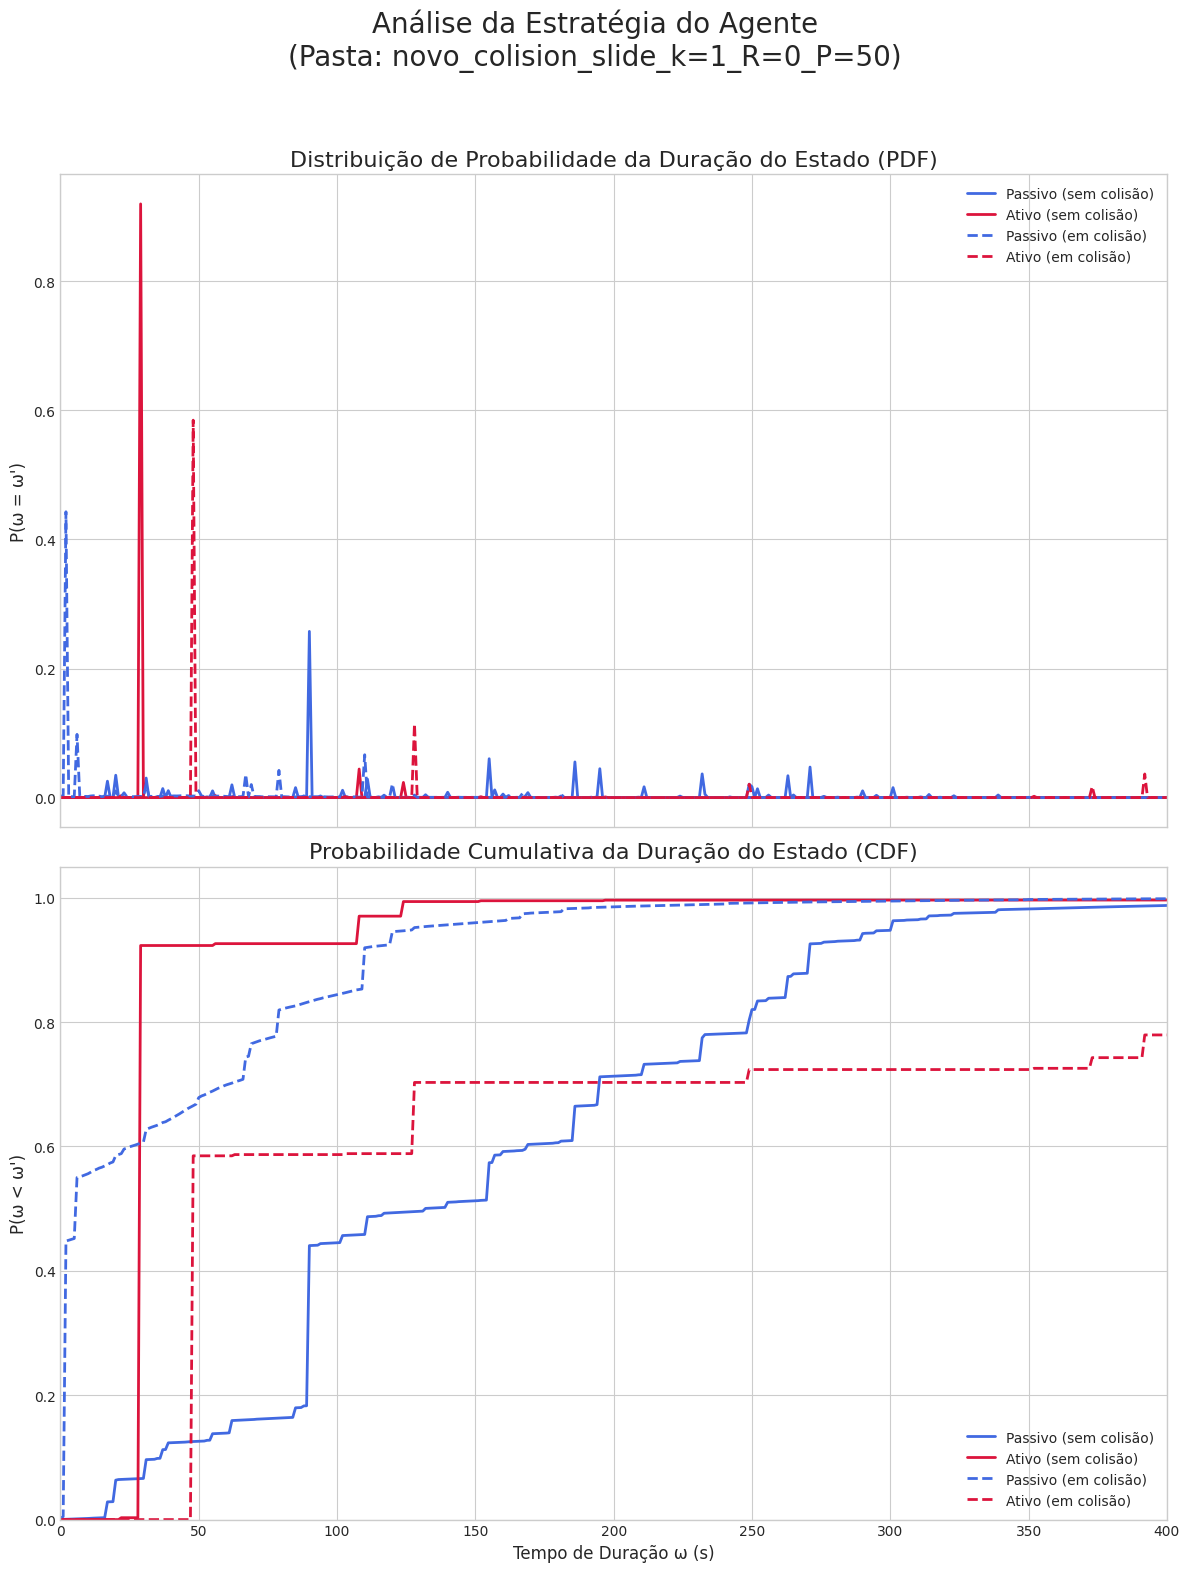

In [43]:

# --- CÉLULA DE EXECUÇÃO E PLOTAGEM ---

# 1. ESPECIFIQUE O CAMINHO DA PASTA AQUI
folder_to_analyze = "../data/models/novo_colision_slide_k=1_R=0_P=50"

# 2. EXECUTE A ANÁLISE
model_files = find_model_files(folder_to_analyze)

if not model_files:
    print(f"ERRO: Nenhum par de arquivos (h_matrix.txt, args.json) encontrado em '{folder_to_analyze}'")
else:
    print(f"Encontrados {len(model_files)} modelos. Calculando a Matriz H média...")
    
    avg_h, args = get_average_h_matrix(model_files)
    
    # Define os estados que queremos analisar
    states_to_analyze = [
        {'state_phi': 0, 'colision_lambda': 0, 'label': 'Passivo (sem colisão)'},
        {'state_phi': 1, 'colision_lambda': 0, 'label': 'Ativo (sem colisão)'}
    ]
    if bool(args['colision']):
        states_to_analyze.extend([
            {'state_phi': 0, 'colision_lambda': 1, 'label': 'Passivo (em colisão)'},
            {'state_phi': 1, 'colision_lambda': 1, 'label': 'Ativo (em colisão)'}
        ])

    # --- Plotagem ---
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 16), sharex=True)
    
    print("\n--- Tempos Médios de Duração ⟨ω⟩ ---")
    
    colors = {'Passivo': 'royalblue', 'Ativo': 'crimson'}
    linestyles = {'sem colisão': '-', 'em colisão': '--'}

    for params in states_to_analyze:
        phi = params['state_phi']
        lmb = params['colision_lambda']
        
        # Ignora análise de colisão se o modelo não a usa
        if lmb == 1 and not args['colision']:
            continue
            
        t, pdf, cdf, avg_w = calculate_strategy_metrics(avg_h, args, phi, lmb)
        
        base_label = 'Passivo' if phi == 0 else 'Ativo'
        col_label = 'sem colisão' if lmb == 0 else 'em colisão'
        full_label = f"{base_label} ({col_label})"
        
        print(f"⟨ω⟩ para {full_label}: {avg_w:.2f} s")
        
        # Gráfico 1: PDF - P(ω = ω')
        ax1.plot(t, pdf, color=colors[base_label], linestyle=linestyles[col_label], label=full_label, lw=2)
        
        # Gráfico 2: CDF - P(ω < ω')
        ax2.plot(t, cdf, color=colors[base_label], linestyle=linestyles[col_label], label=full_label, lw=2)

    ax1.set_title('Distribuição de Probabilidade da Duração do Estado (PDF)', fontsize=16)
    ax1.set_ylabel('P(ω = ω\')', fontsize=12)
    ax1.legend()
    ax1.grid(True)

    ax2.set_title('Probabilidade Cumulativa da Duração do Estado (CDF)', fontsize=16)
    ax2.set_xlabel('Tempo de Duração ω (s)', fontsize=12)
    ax2.set_ylabel('P(ω < ω\')', fontsize=12)
    ax2.legend()
    ax2.grid(True)
    ax2.set_ylim(0, 1.05)
    ax2.set_xlim(0, 400)
    
    fig.suptitle(f'Análise da Estratégia do Agente\n(Pasta: {os.path.basename(folder_to_analyze)})', fontsize=20, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()